# Customer Churn Model Interpretation

This notebook interprets the final churn prediction model using feature importance and SHAP analysis.

Goals:
- Identify key drivers of churn
- Understand how features influence model predictions
- Extract actionable business insights

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

d:\Projects\Churn Analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Model and Dataset

We load the processed dataset and the final tuned XGBoost model selected in the previous notebook.

In [2]:
df = pd.read_csv("../data/processed/telco_final_processed.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [3]:
# Loading tuned model
xgb_model = joblib.load("../models/xgb_tuned_model.pkl")

## 2. Global Feature Importance

Feature importance from XGBoost helps identify which variables contribute most to churn prediction.

Higher importance indicates stronger influence on model decisions.

In [4]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
20,Contract_Two year,0.284315
19,Contract_One year,0.215786
11,InternetService_Fiber optic,0.112981
12,InternetService_No,0.058199
22,PaymentMethod_Electronic check,0.038754
18,StreamingMovies_Yes,0.036129
4,tenure,0.035276
6,PaperlessBilling,0.023632
13,OnlineSecurity_Yes,0.021279
17,StreamingTV_Yes,0.019629


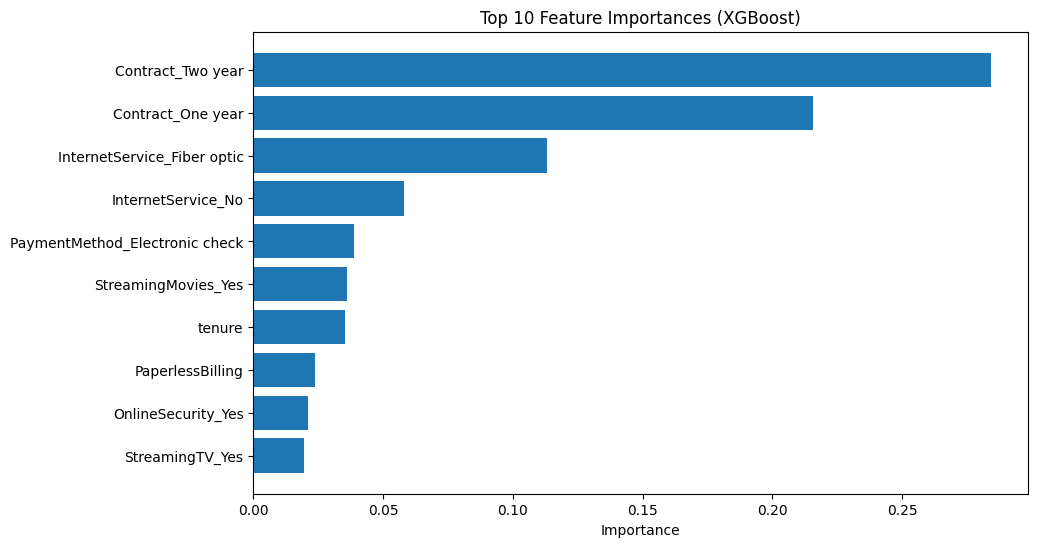

In [5]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"][:10][::-1],
         feature_importance["Importance"][:10][::-1])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

### Observations

Contract type is the strongest driver of churn prediction.  
Customers on long-term contracts show significantly lower churn risk.

Internet service type and payment methods also contribute meaningfully to predictions.

## 3. SHAP Analysis

SHAP (SHapley Additive exPlanations) provides detailed insight into how each feature influences predictions.

Unlike simple feature importance, SHAP shows:
- direction of impact
- magnitude of influence
- feature interactions

In [6]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X)

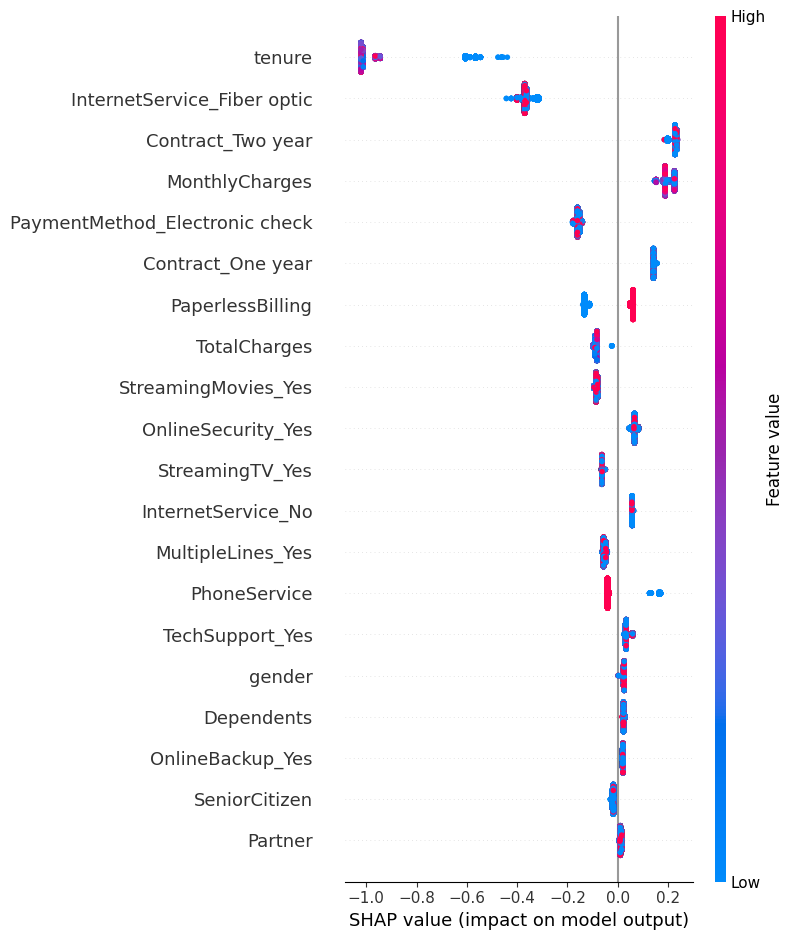

In [7]:
shap.summary_plot(shap_values, X)

### Key Insights from SHAP Summary

Several features strongly influence churn predictions:

• **Tenure** – Customers with shorter tenure have higher churn risk.

• **Contract Type** – Two-year and one-year contracts significantly reduce churn likelihood.

• **Monthly Charges** – Higher charges increase churn probability.

• **Fiber Internet Service** – Fiber customers appear more likely to churn compared to DSL users.

• **Electronic Check Payment** – Customers using electronic check payments show higher churn risk.

## 4. Feature Interaction Analysis

SHAP dependence plots show how individual features influence churn probability across their value range.

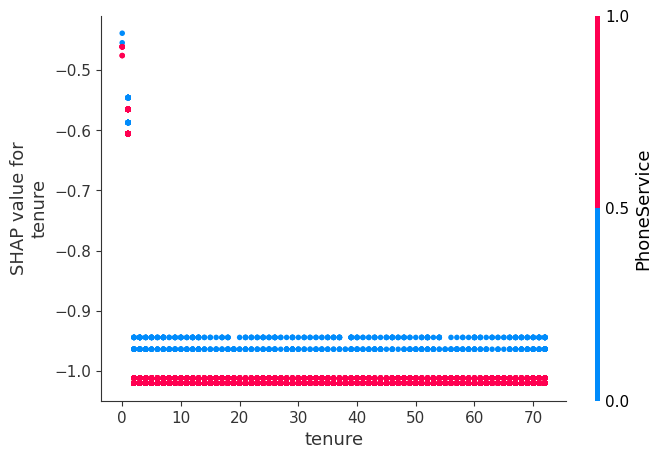

In [8]:
shap.dependence_plot("tenure", shap_values, X)

Lower tenure values push predictions toward churn, indicating that new customers are more likely to leave.

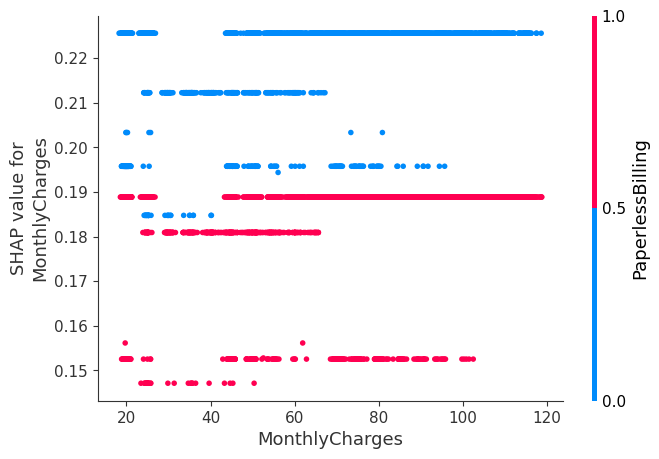

In [9]:
shap.dependence_plot("MonthlyCharges", shap_values, X)

Higher monthly charges increase churn risk, suggesting cost sensitivity among customers.

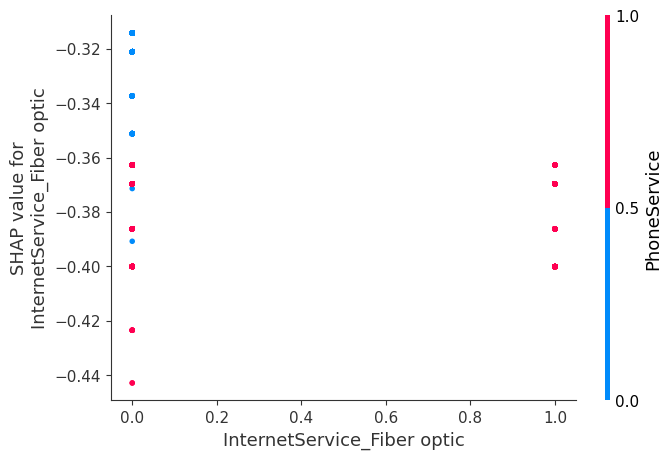

In [10]:
shap.dependence_plot("InternetService_Fiber optic", shap_values, X)

Customers with fiber internet appear more prone to churn, potentially due to higher pricing or service expectations.

## 5. Business Insights and Recommendations

Based on the model interpretation:

1. **Encourage long-term contracts**
   - Contract length is the strongest churn stabilizer.

2. **Focus retention efforts on new customers**
   - Early-stage customers show the highest churn risk.

3. **Monitor pricing sensitivity**
   - Higher monthly charges correlate with churn.

4. **Investigate fiber internet churn**
   - Fiber users appear disproportionately represented among churners.

5. **Target electronic check users**
   - This group shows higher churn probability.

These insights can guide targeted retention campaigns and pricing strategies.